# SVM Basics

A short guide to SVM and support vectors.

## Why SVM?

SVM draws a boundary that keeps the classes as far apart as possible.

In [31]:
from sklearn.datasets import load_iris
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

## Load Iris Data

We use two features so the boundary is easy to see.

In [32]:
iris = load_iris(as_frame=True)
iris_data = iris.frame.copy()
iris_data.columns = [column.replace(' (cm)', '').replace(' ', '_') for column in iris_data.columns]

feature_x = 'petal_length'
feature_y = 'petal_width'
X_iris = iris_data[[feature_x, feature_y]]
y_iris = iris.target

print('Features:', feature_x, 'and', feature_y)
print('Data shape:', X_iris.shape)

Features: petal_length and petal_width
Data shape: (150, 2)


## Train the Model

Split the data, fit the SVM, and check accuracy.

In [33]:
X_train, X_test, y_train, y_test = train_test_split(
    X_iris,
    y_iris,
    test_size=0.2,
    random_state=42,
    stratify=y_iris,
)

iris_model = Pipeline(
    steps=[
        ('scaler', StandardScaler()),
        ('svm', SVC(kernel='rbf', C=2.0, gamma='scale', class_weight='balanced')),
    ]
)

iris_model.fit(X_train, y_train)
y_pred = iris_model.predict(X_test)

print('Classes:', list(iris.target_names))
print(f'Test accuracy: {accuracy_score(y_test, y_pred):.4f}')
print('\nClassification report:')
print(classification_report(y_test, y_pred, target_names=iris.target_names))
print('\nConfusion matrix:')
print(confusion_matrix(y_test, y_pred))

Classes: [np.str_('setosa'), np.str_('versicolor'), np.str_('virginica')]
Test accuracy: 0.9333

Classification report:
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       0.90      0.90      0.90        10
   virginica       0.90      0.90      0.90        10

    accuracy                           0.93        30
   macro avg       0.93      0.93      0.93        30
weighted avg       0.93      0.93      0.93        30


Confusion matrix:
[[10  0  0]
 [ 0  9  1]
 [ 0  1  9]]


## Plot the Boundary

The chart shows the classes and the support vectors.

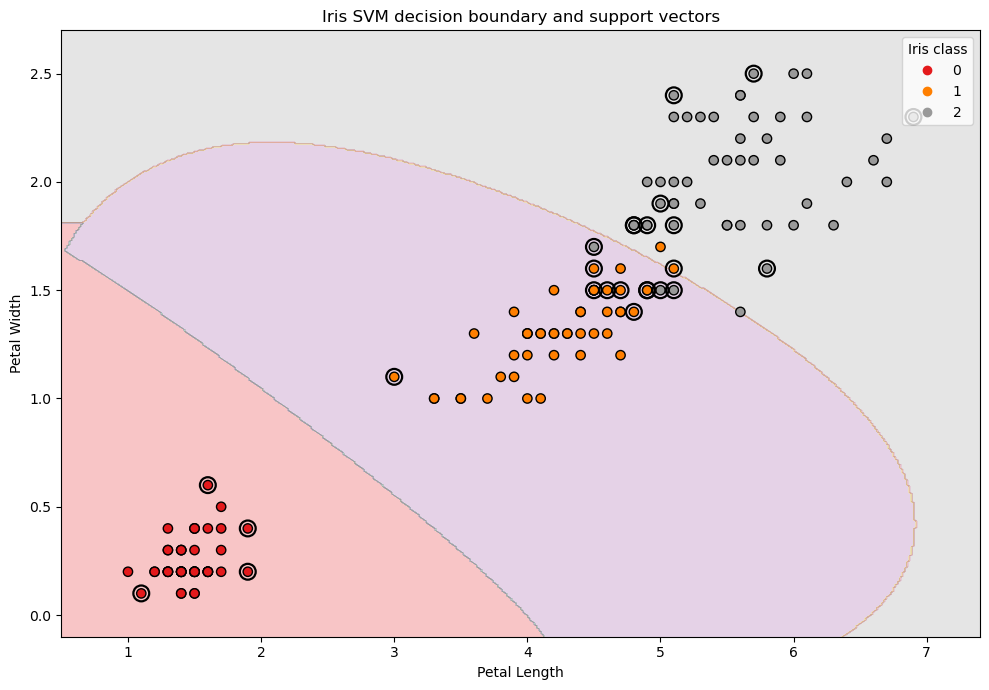

In [34]:
x_min, x_max = X_iris[feature_x].min() - 0.5, X_iris[feature_x].max() + 0.5
y_min, y_max = X_iris[feature_y].min() - 0.2, X_iris[feature_y].max() + 0.2
xx, yy = np.meshgrid(np.linspace(x_min, x_max, 400), np.linspace(y_min, y_max, 400))
grid = pd.DataFrame({feature_x: xx.ravel(), feature_y: yy.ravel()})
zz = iris_model.predict(grid).reshape(xx.shape)

support_vectors_scaled = iris_model.named_steps['svm'].support_vectors_
support_vectors = iris_model.named_steps['scaler'].inverse_transform(support_vectors_scaled)

plt.figure(figsize=(10, 7))
plt.contourf(xx, yy, zz, alpha=0.25, cmap='Set1')
scatter = plt.scatter(
    X_iris[feature_x],
    X_iris[feature_y],
    c=y_iris,
    cmap='Set1',
    edgecolor='k',
    s=45,
)
plt.scatter(
    support_vectors[:, 0],
    support_vectors[:, 1],
    s=130,
    facecolors='none',
    edgecolors='black',
    linewidths=1.6,
    label='Support vectors',
)

plt.xlabel('Petal Length')
plt.ylabel('Petal Width')
plt.title('Iris SVM decision boundary and support vectors')
plt.legend(*scatter.legend_elements(), title='Iris class', loc='upper right')
plt.tight_layout()
plt.show()